# IDS 705 — Group 10: Vulnerability of Medical AI
## Kaggle Chest X-Ray Dataset — Clean Baseline Evaluation
### ResNet-18 (224×224) · Generalization Test

This notebook tests the pretrained ResNet-18 (trained on MedMNIST) on the
original Kaggle chest X-ray dataset to evaluate how well findings generalize
beyond the MedMNIST benchmark.

**Dataset**: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)  
**Split used**: Test only (624 images — 234 Normal + 390 Pneumonia)  
**Model**: ResNet-18 pretrained on PneumoniaMNIST+ · Zenodo [7782114](https://zenodo.org/records/7782114)

## 0. Install & import

In [1]:
!pip install kaggle medmnist scikit-learn --quiet

import os, zipfile
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score,
    f1_score, confusion_matrix
)
from medmnist import INFO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.2 MB/s eta 0:00:00
Device: cpu


## 1. Kaggle API setup

⚠️ **Paste your new API token below — never share this token publicly**

In [2]:
# ── Paste your credentials here ───────────────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = 'ShellyCYH'
os.environ['KAGGLE_KEY']      = 'KGAT_aab5a61ed0629e514c8b5643cfc2bc3b'
# ─────────────────────────────────────────────────────────────────────────────

print(f'Kaggle username: {os.environ["KAGGLE_USERNAME"]}')
print('Kaggle key: [hidden]')
print('Kaggle API ready ✓')

Kaggle username: ShellyCYH
Kaggle key: [hidden]
Kaggle API ready ✓


## 2. Download dataset from Kaggle

In [3]:
KAGGLE_DATA_DIR = './kaggle_data'
TEST_DIR        = os.path.join(KAGGLE_DATA_DIR, 'chest_xray', 'test')

if not os.path.exists(TEST_DIR):
    print('Downloading chest-xray-pneumonia dataset from Kaggle...')
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p {KAGGLE_DATA_DIR}
    print('Extracting...')
    !unzip -q {KAGGLE_DATA_DIR}/chest-xray-pneumonia.zip -d {KAGGLE_DATA_DIR}
    print('Done.')
else:
    print(f'Dataset already present: {TEST_DIR}')

# Show test folder structure
print('\nTest folder structure:')
for cls in os.listdir(TEST_DIR):
    cls_path = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_path):
        n = len(os.listdir(cls_path))
        print(f'  {cls}: {n} images')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:34<00:00, 71.0MB/s]

Extracting...
Done.

Test folder structure:
  PNEUMONIA: 390 images
  NORMAL: 234 images


## 3. Download model weights

In [4]:
WEIGHTS_DIR  = './weights'
WEIGHTS_FILE = os.path.join(WEIGHTS_DIR, 'resnet18_224_1.pth')
ZIP_URL      = 'https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip?download=1'
ZIP_PATH     = 'weights_pneumoniamnist.zip'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

if not os.path.exists(WEIGHTS_FILE):
    print('Downloading weights from Zenodo...')
    response = requests.get(ZIP_URL, stream=True)
    response.raise_for_status()
    with open(ZIP_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        for member in zf.namelist():
            if member.endswith('.pth'):
                fname = os.path.basename(member)
                with zf.open(member) as src, open(os.path.join(WEIGHTS_DIR, fname), 'wb') as dst:
                    dst.write(src.read())
    print('Done.')
else:
    print(f'Weights already present: {WEIGHTS_FILE}')

Done.


## 4. Load model

In [5]:
info      = INFO['pneumoniamnist']
n_classes = len(info['label'])  # 2

model = tv_models.resnet18(weights=None, num_classes=n_classes)
ckpt  = torch.load(WEIGHTS_FILE, map_location=device)
state_dict = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
model.load_state_dict(state_dict, strict=True)
model.to(device)
model.eval()
print(f'Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters ✓')

Model loaded — 11,177,538 parameters ✓


## 5. Build Kaggle test dataset

Key points:
- Images are raw JPEGs at variable resolutions → must resize to 224×224
- Use `PIL.Image.NEAREST` to match the MedMNIST training pipeline
- Convert to RGB (some images may be grayscale)
- Same normalization as MedMNIST: mean=0.5, std=0.5
- `ImageFolder` assigns labels alphabetically: NORMAL=0, PNEUMONIA=1 ✓

In [6]:
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]
SIZE = 224
BATCH_SIZE = 128

kaggle_transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

kaggle_test_ds = ImageFolder(
    root=TEST_DIR,
    transform=kaggle_transform
)

print(f'Class mapping : {kaggle_test_ds.class_to_idx}')
print(f'Total images  : {len(kaggle_test_ds)}')

# Verify label mapping matches MedMNIST
class_map = kaggle_test_ds.class_to_idx
assert class_map['NORMAL'] == 0,    'ERROR: NORMAL should be 0'
assert class_map['PNEUMONIA'] == 1, 'ERROR: PNEUMONIA should be 1'
print('Label mapping verified ✓  (NORMAL=0, PNEUMONIA=1)')

kaggle_loader = DataLoader(
    kaggle_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)
print(f'DataLoader ready ✓')

Class mapping : {'NORMAL': 0, 'PNEUMONIA': 1}
Total images  : 624
Label mapping verified ✓  (NORMAL=0, PNEUMONIA=1)
DataLoader ready ✓


## 6. Visual preview — sample Kaggle images

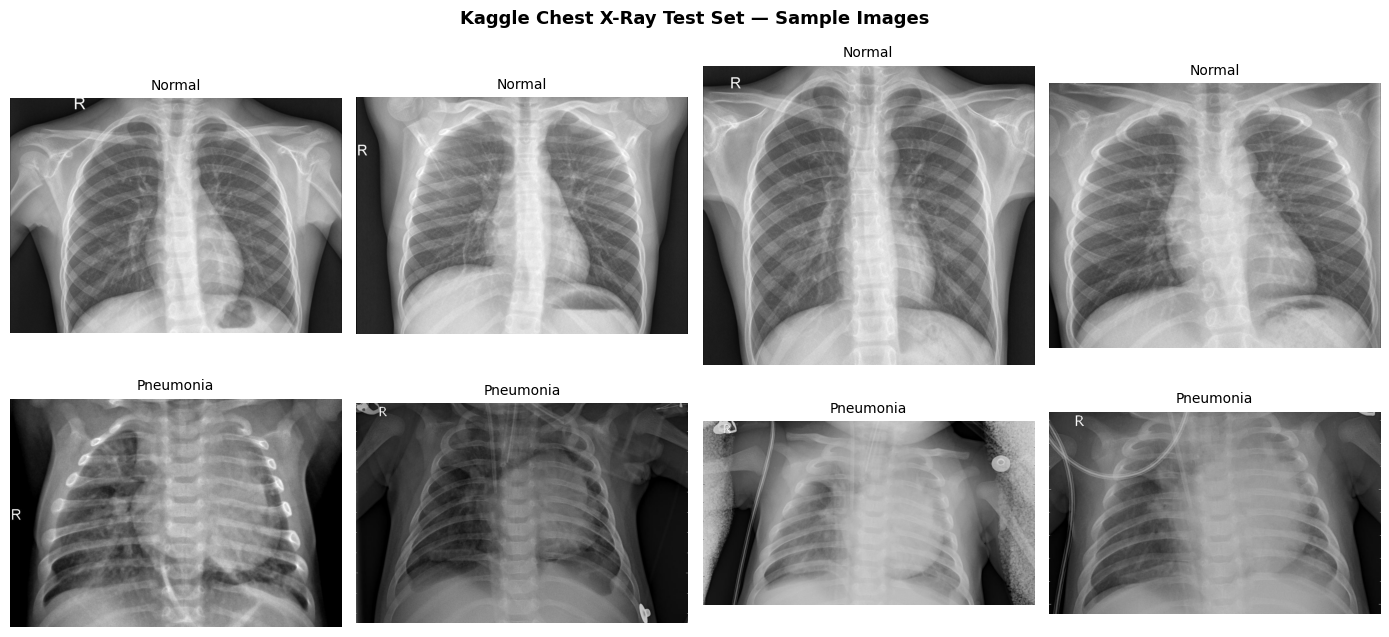

Preview complete ✓


In [7]:
# Show 4 Normal and 4 Pneumonia samples from the Kaggle test set
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
label_names = {0: 'Normal', 1: 'Pneumonia'}

shown = {0: 0, 1: 0}
raw_ds = ImageFolder(root=TEST_DIR, transform=None)

for img_pil, lbl in raw_ds:
    if shown[lbl] < 4:
        row = lbl
        col = shown[lbl]
        axes[row, col].imshow(img_pil.convert('RGB'))
        axes[row, col].set_title(f'{label_names[lbl]}', fontsize=10)
        axes[row, col].axis('off')
        shown[lbl] += 1
    if shown[0] == 4 and shown[1] == 4:
        break

fig.suptitle('Kaggle Chest X-Ray Test Set — Sample Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Preview complete ✓')

## 7. Run inference

In [8]:
print('Running inference on Kaggle test set...')
model.eval()
all_scores, all_labels = [], []

with torch.no_grad():
    for images, labels in kaggle_loader:
        logits = model(images.to(device))
        scores = torch.softmax(logits, dim=1)
        all_scores.append(scores.cpu().numpy())
        all_labels.append(labels.numpy())

y_score = np.concatenate(all_scores)   # (N, 2)
y_true  = np.concatenate(all_labels)   # (N,)
y_pred  = (y_score[:, 1] >= 0.5).astype(int)

print(f'Inference complete — {len(y_true)} images ✓')

Running inference on Kaggle test set...
Inference complete — 624 images ✓


## 8. Compute metrics

In [9]:
auc  = roc_auc_score(y_true, y_score[:, 1])
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

kaggle_results = {
    'accuracy' : acc,
    'auroc'    : auc,
    'precision': prec,
    'recall'   : rec,
    'f1'       : f1,
}

print('=== Kaggle Test Set Results ===')
print(f'  Images    : {len(y_true)} ({sum(y_true==0)} Normal, {sum(y_true==1)} Pneumonia)')
print(f'  Accuracy  : {acc:.4f}')
print(f'  AUROC     : {auc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'\n  Confusion Matrix:')
print(f'  TN={tn}  FP={fp}')
print(f'  FN={fn}  TP={tp}')
print(f'  Missed pneumonia cases (FN): {fn}')

=== Kaggle Test Set Results ===
  Images    : 624 (234 Normal, 390 Pneumonia)
  Accuracy  : 0.8846
  AUROC     : 0.9562
  Precision : 0.8786
  Recall    : 0.9462
  F1        : 0.9111

  Confusion Matrix:
  TN=183  FP=51
  FN=21  TP=369
  Missed pneumonia cases (FN): 21


## 9. Confusion matrix plot

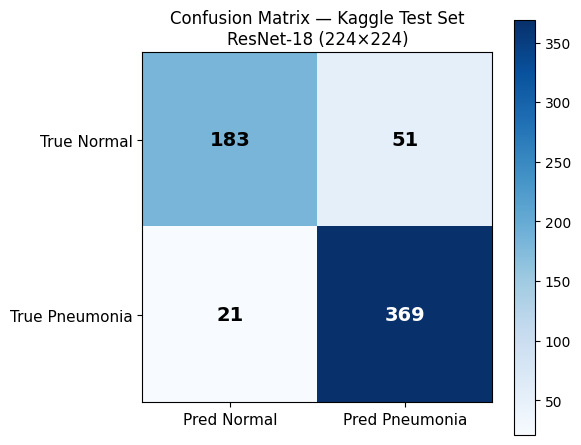

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_array = np.array([[tn, fp], [fn, tp]])

im = ax.imshow(cm_array, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Normal', 'Pred Pneumonia'], fontsize=11)
ax.set_yticklabels(['True Normal', 'True Pneumonia'], fontsize=11)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_array[i, j]),
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm_array[i, j] > cm_array.max()/2 else 'black')

plt.colorbar(im, ax=ax)
ax.set_title('Confusion Matrix — Kaggle Test Set\nResNet-18 (224×224)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. MedMNIST vs Kaggle comparison

Paste your MedMNIST baseline results below from your main notebook.

In [11]:
# ── Paste your MedMNIST clean baseline results here ───────────────────────────
medmnist_results = {
    'accuracy' : 0.8942,   # update with your actual numbers
    'auroc'    : 0.9553,
    'precision': 0.9200,   # update
    'recall'   : 0.9744,
    'f1'       : 0.9464,   # update
}
medmnist_n   = 624
medmnist_fn  = 10
# ─────────────────────────────────────────────────────────────────────────────

print('=== Dataset Comparison — Clean Baseline ===')
print(f'{"Metric":<12} {"MedMNIST":>10} {"Kaggle":>10} {"Difference":>12}')
print('-' * 48)
for metric in ['accuracy', 'auroc', 'precision', 'recall', 'f1']:
    med_val  = medmnist_results[metric]
    kag_val  = kaggle_results[metric]
    diff     = kag_val - med_val
    direction = '↑' if diff > 0 else '↓'
    print(f'{metric:<12} {med_val:>10.4f} {kag_val:>10.4f} {diff:>+11.4f} {direction}')

print(f'\n{"Images":<12} {medmnist_n:>10} {len(y_true):>10}')
print(f'{"FN (missed)":<12} {medmnist_fn:>10} {fn:>10}')

# Summary
acc_diff = kaggle_results['accuracy'] - medmnist_results['accuracy']
print(f'\nKey finding:')
if abs(acc_diff) < 0.02:
    print(f'  Model generalizes well — accuracy difference is only {acc_diff:+.4f}')
elif acc_diff < 0:
    print(f'  Model performs worse on Kaggle — accuracy drop of {abs(acc_diff):.4f}')
    print(f'  Suggests model may be overfitted to MedMNIST preprocessing')
else:
    print(f'  Model performs better on Kaggle — accuracy gain of {acc_diff:.4f}')

=== Dataset Comparison — Clean Baseline ===
Metric         MedMNIST     Kaggle   Difference
------------------------------------------------
accuracy         0.8942     0.8846     -0.0096 ↓
auroc            0.9553     0.9562     +0.0009 ↑
precision        0.9200     0.8786     -0.0414 ↓
recall           0.9744     0.9462     -0.0282 ↓
f1               0.9464     0.9111     -0.0353 ↓

Images              624        624
FN (missed)          10         21

Key finding:
  Model generalizes well — accuracy difference is only -0.0096


## 11. Comparison bar chart

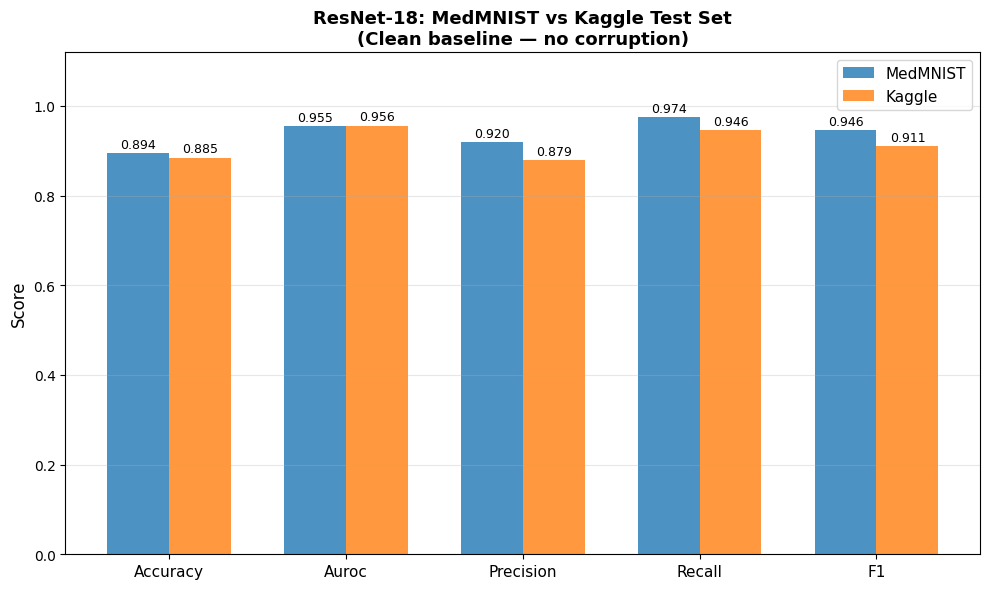

Comparison chart complete ✓


In [12]:
metrics     = ['accuracy', 'auroc', 'precision', 'recall', 'f1']
med_vals    = [medmnist_results[m] for m in metrics]
kaggle_vals = [kaggle_results[m]   for m in metrics]

x   = np.arange(len(metrics))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, med_vals,    w, label='MedMNIST',
               color='tab:blue', alpha=0.8)
bars2 = ax.bar(x + w/2, kaggle_vals, w, label='Kaggle',
               color='tab:orange', alpha=0.8)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('ResNet-18: MedMNIST vs Kaggle Test Set\n(Clean baseline — no corruption)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print('Comparison chart complete ✓')

## 12. Save results

In [13]:
rows = [
    {'dataset': 'MedMNIST', 'n_images': medmnist_n,   **medmnist_results, 'FN': medmnist_fn},
    {'dataset': 'Kaggle',   'n_images': len(y_true),  **kaggle_results,   'FN': fn},
]
df = pd.DataFrame(rows).set_index('dataset')
df = df[['n_images','accuracy','precision','recall','f1','auroc','FN']].round(4)
df.to_csv('kaggle_vs_medmnist.csv')
print(df.to_string())
print('\nSaved: kaggle_vs_medmnist.csv')

          n_images  accuracy  precision  recall      f1   auroc  FN
dataset                                                            
MedMNIST       624    0.8942     0.9200  0.9744  0.9464  0.9553  10
Kaggle         624    0.8846     0.8786  0.9462  0.9111  0.9562  21

Saved: kaggle_vs_medmnist.csv


## 13. Corruption


In [14]:
# ── Gamma attack definitions ──────────────────────────────────────────────────
GAMMA_LEVELS = {
    'Gamma Overexposed': [0.9, 0.7, 0.5, 0.3, 0.1],   # γ<1, brightens darks
    'Gamma Underexposed': [1.5, 2.0, 3.0, 4.0, 5.0],  # γ>1, darkens brights
}

def apply_gamma(t, gamma):
    t_01    = (t + 1) / 2
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)

def make_gamma_transform(gamma):
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
        transforms.Lambda(lambda t: apply_gamma(t, gamma))
    ])

print('Gamma transforms defined ✓')

Gamma transforms defined ✓


In [15]:
# ── Run gamma evaluation ──────────────────────────────────────────────────────
gamma_results = {}   # {attack_name: {level: metrics}}

for attack_name, gammas in GAMMA_LEVELS.items():
    print(f'\n--- {attack_name} ---')
    gamma_results[attack_name] = {}
    for level_idx, gamma in enumerate(gammas):
        ds = ImageFolder(root=TEST_DIR,
                         transform=make_gamma_transform(gamma))
        loader = DataLoader(ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=2)
        model.eval()
        all_scores, all_labels = [], []
        with torch.no_grad():
            for images, labels in loader:
                logits = model(images.to(device))
                scores = torch.softmax(logits, dim=1)
                all_scores.append(scores.cpu().numpy())
                all_labels.append(labels.numpy())

        y_sc = np.concatenate(all_scores)
        y_tr = np.concatenate(all_labels)
        y_pd = (y_sc[:, 1] >= 0.5).astype(int)

        m = {
            'accuracy' : accuracy_score(y_tr, y_pd),
            'auroc'    : roc_auc_score(y_tr, y_sc[:, 1]),
            'precision': precision_score(y_tr, y_pd, zero_division=0),
            'recall'   : recall_score(y_tr, y_pd, zero_division=0),
            'f1'       : f1_score(y_tr, y_pd, zero_division=0),
        }
        gamma_results[attack_name][level_idx + 1] = m
        print(f'  L{level_idx+1} (γ={gamma}): '
              f'Acc={m["accuracy"]:.4f}  '
              f'AUROC={m["auroc"]:.4f}  '
              f'Recall={m["recall"]:.4f}')

print('\n✓ Gamma evaluation complete')


--- Gamma Overexposed ---
  L1 (γ=0.9): Acc=0.8878  AUROC=0.9553  Recall=0.9538
  L2 (γ=0.7): Acc=0.8510  AUROC=0.9519  Recall=0.9718
  L3 (γ=0.5): Acc=0.7468  AUROC=0.9141  Recall=0.9897
  L4 (γ=0.3): Acc=0.6314  AUROC=0.7038  Recall=1.0000
  L5 (γ=0.1): Acc=0.6250  AUROC=0.5000  Recall=1.0000

--- Gamma Underexposed ---
  L1 (γ=1.5): Acc=0.8638  AUROC=0.9419  Recall=0.9410
  L2 (γ=2.0): Acc=0.7901  AUROC=0.8992  Recall=0.9462
  L3 (γ=3.0): Acc=0.6571  AUROC=0.7956  Recall=0.9897
  L4 (γ=4.0): Acc=0.6282  AUROC=0.6838  Recall=1.0000
  L5 (γ=5.0): Acc=0.6250  AUROC=0.6751  Recall=1.0000

✓ Gamma evaluation complete


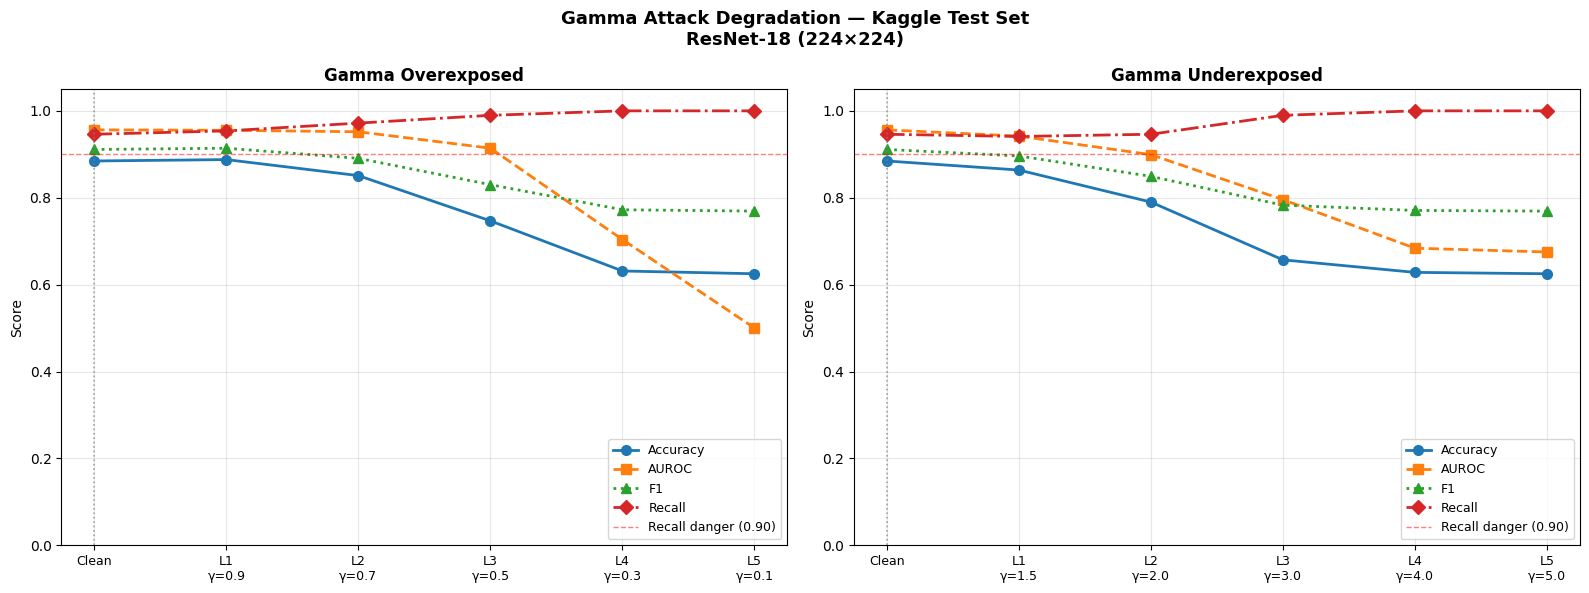

In [16]:
# ── Degradation curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_pos    = list(range(6))
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']
styles   = [('o-','tab:blue'), ('s--','tab:orange'),
            ('^:','tab:green'), ('D-.','tab:red')]
metrics_to_plot = ['accuracy', 'auroc', 'f1', 'recall']

for ax, attack_name in zip(axes, GAMMA_LEVELS.keys()):
    gammas = GAMMA_LEVELS[attack_name]
    series = {
        m: [kaggle_results[m]] + [gamma_results[attack_name][l][m]
                                   for l in range(1, 6)]
        for m in metrics_to_plot
    }
    for (style, color), (metric, values) in zip(styles, series.items()):
        ax.plot(x_pos, values, style, color=color,
                label=metric.upper() if metric == 'auroc' else metric.capitalize(),
                linewidth=2, markersize=7)

    # Annotate gamma values on x axis
    gamma_labels = ['Clean'] + [f'L{i+1}\nγ={g}' for i, g in enumerate(gammas)]
    ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.axhline(y=0.90, color='red', linestyle='--', linewidth=1,
               alpha=0.5, label='Recall danger (0.90)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(gamma_labels, fontsize=9)
    ax.set_title(attack_name, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Gamma Attack Degradation — Kaggle Test Set\nResNet-18 (224×224)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

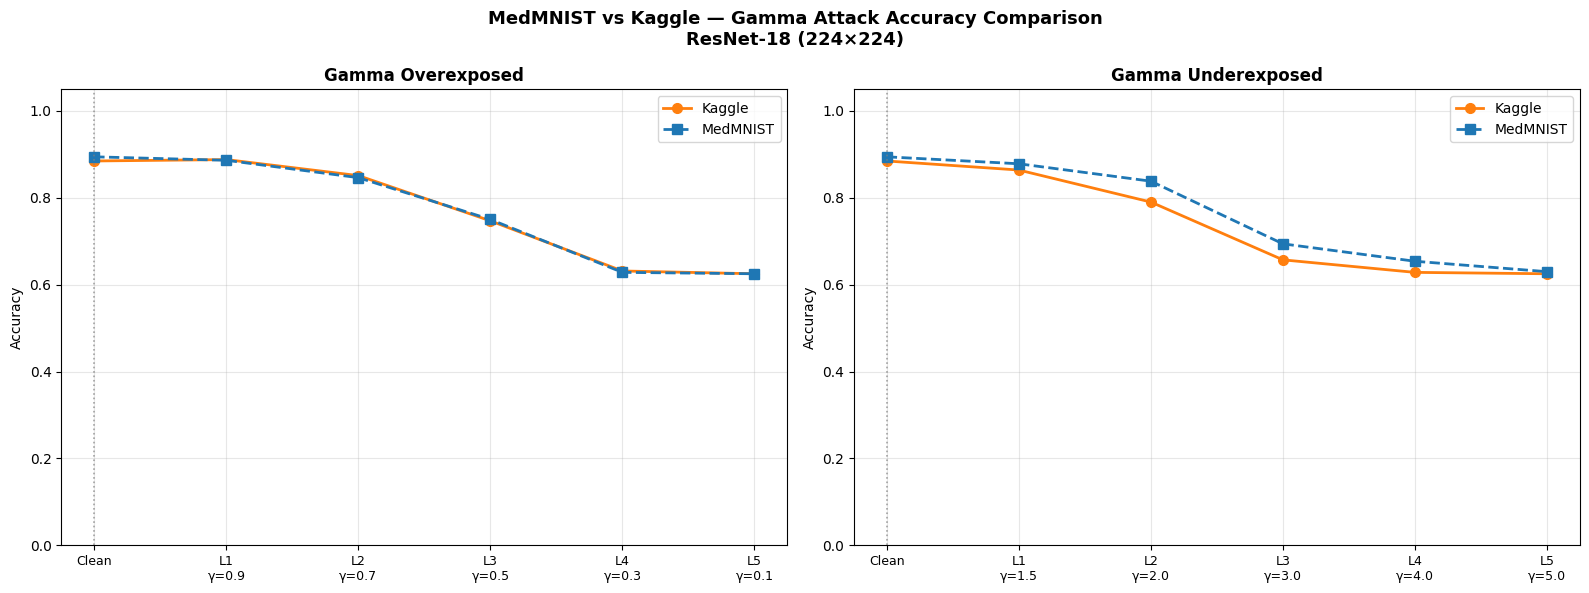

In [20]:
# ── MedMNIST vs Kaggle gamma comparison ──────────────────────────────────────
# Paste your MedMNIST gamma results here from Notebook 1
medmnist_gamma = {
    'Gamma Overexposed' : [0.8862, 0.8462, 0.7500, 0.6282, 0.6250],
    'Gamma Underexposed': [0.8782, 0.8381, 0.6939, 0.6538, 0.6298],
}
# Replace 0.0000 with your actual MedMNIST accuracy values at each level

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, attack_name in zip(axes, GAMMA_LEVELS.keys()):
    kaggle_vals  = [kaggle_results['accuracy']] + \
                   [gamma_results[attack_name][l]['accuracy'] for l in range(1, 6)]
    medmnist_vals = [medmnist_results['accuracy']] + medmnist_gamma[attack_name]

    ax.plot(x_pos, kaggle_vals,   'o-', color='tab:orange',
            label='Kaggle',   linewidth=2, markersize=7)
    ax.plot(x_pos, medmnist_vals, 's--', color='tab:blue',
            label='MedMNIST', linewidth=2, markersize=7)

    gammas = GAMMA_LEVELS[attack_name]
    gamma_labels = ['Clean'] + [f'L{i+1}\nγ={g}' for i, g in enumerate(gammas)]
    ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(gamma_labels, fontsize=9)
    ax.set_title(attack_name, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle('MedMNIST vs Kaggle — Gamma Attack Accuracy Comparison\nResNet-18 (224×224)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = [{'dataset': 'Kaggle (clean)', 'attack': '-', 'level': '-',
         **{k: round(v, 4) for k, v in kaggle_results.items()}}]

for attack_name in GAMMA_LEVELS:
    for level in range(1, 6):
        m = gamma_results[attack_name][level]
        rows.append({
            'dataset': 'Kaggle',
            'attack' : attack_name,
            'level'  : str(level),
            **{k: round(v, 4) for k, v in m.items()}
        })

df_gamma = pd.DataFrame(rows).set_index(['dataset', 'attack', 'level'])
df_gamma = df_gamma[['accuracy', 'precision', 'recall', 'f1', 'auroc']]
df_gamma.to_csv('kaggle_gamma_results.csv')
print(df_gamma.to_string())
print('\nSaved: kaggle_gamma_results.csv')

                                         accuracy  precision  recall      f1   auroc
dataset        attack             level                                             
Kaggle (clean) -                  -        0.8846     0.8786  0.9462  0.9111  0.9562
Kaggle         Gamma Overexposed  1        0.8878     0.8774  0.9538  0.9140  0.9553
                                  2        0.8510     0.8221  0.9718  0.8907  0.9519
                                  3        0.7468     0.7148  0.9897  0.8301  0.9141
                                  4        0.6314     0.6290  1.0000  0.7723  0.7038
                                  5        0.6250     0.6250  1.0000  0.7692  0.5000
               Gamma Underexposed 1        0.8638     0.8555  0.9410  0.8962  0.9419
                                  2        0.7901     0.7704  0.9462  0.8493  0.8992
                                  3        0.6571     0.6477  0.9897  0.7830  0.7956
                                  4        0.6282     0.6270  1.0